# Multiple comparisons correction

When you test colocalizations with 30 PET receptor maps, you're running 30 statistical tests at once. If you use a threshold of α=0.05, you'd expect 1–2 false positives by chance alone even if nothing is truly significant. This is the multiple comparisons problem.

NiSpace provides several correction methods. This notebook explains what they do and when to use each one.

In [2]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import pandas as pd

In [3]:
from nispace.datasets import fetch_reference
from nispace.io import load_img
from nispace.api import NiSpace

# set up and run the pain analysis
pet_maps = fetch_reference("pet", parcellation="Yan200",
                           collection="UniqueTracers", print_references=False)
pain_map = load_img("neuroquery/pain.nii.gz")

nsp = NiSpace(x=pet_maps, y=pain_map, y_labels="Pain",
              parcellation="Yan200", seed=42, n_proc=4)
nsp.fit()
nsp.colocalize("spearman")
nsp.permute("maps", n_perm=1000, p_tails="upper")

p_values = nsp.get_p_values()
print(f"Testing {p_values.shape[1]} receptor maps simultaneously")

INFO | 30/06/26 13:06:02 | nispace.datasets: Loading pet maps.


INFO | 30/06/26 13:06:02 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 30/06/26 13:06:02 | nispace.datasets: Filtering maps by collection.


INFO | 30/06/26 13:06:02 | nispace.datasets: Loading data parcellated with 'Yan200'


INFO | 30/06/26 13:06:02 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


...

INFO | 30/06/26 13:06:11 | nispace.core.permute: Z-standardizing null maps.


Processing null arrays (4 proc): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 927.81it/s]

Null colocalizations (spearman, 4 proc): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 7243.02it/s]

INFO | 30/06/26 13:06:15 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'upper'}).


Testing 29 receptor maps simultaneously


## Methods overview

NiSpace provides two categories of multiple comparison correction:

- **Empirical** (use the permutation null distribution): Meff, maxT, step-maxT
- **Classical** (operate on p-values directly): FDR (Benjamini-Hochberg), Bonferroni, and any statsmodels-compatible method

The workflow is the same for all methods: call `correct_p()` to compute and store the corrected p-values, then retrieve them with `get_p_values()`:

```python
nsp.correct_p(mc_method="meff")              # compute and store
p_corr = nsp.get_p_values(mc_method="meff")  # retrieve
```

| Method | Controls | When to use |
|--------|----------|-------------|
| Meff (Galwey) | FWER | **NiSpace default**; adapts to inter-map correlations |
| maxT / step-maxT | FWER | When stats are comparable across maps (Spearman, Pearson, standardized beta) |
| FDR-BH | FDR | When FWER control is too strict |
| Bonferroni | FWER | Rarely — Meff is strictly better when tests are correlated |

## Meff — the NiSpace default

The 29 PET receptor maps are not independent — serotonin receptors, dopamine transporters, and cholinergic markers all tend to co-localize. Standard Bonferroni ignores this correlation structure and therefore over-corrects.

Meff estimates the *effective number of independent tests* from the eigenvalue spectrum of the inter-map correlation matrix, then applies a Sidak correction using this smaller effective number. Because it adapts to the actual correlation structure of your X maps rather than assuming independence, it is the NiSpace default.

Two variants are available — `"meff"` resolves to the Galwey method:
- `"meff"` / `"meff_galwey"` — **default**; Galwey (2009), *Genet Epidemiol*
- `"meff_li_ji"` — Li & Ji (2005), *Ann Hum Genet*; slightly different eigenvalue weighting

Calling `correct_p()` with no arguments uses Meff (Galwey).

In [4]:
alpha = 0.05

nsp.correct_p(mc_method="meff")   # default; mc_method can be omitted
p_meff = nsp.get_p_values(mc_method="meff")

print(f"Uncorrected (p < {alpha}): {(p_values < alpha).sum(axis=1).values[0]} significant")
print(f"Meff        (p < {alpha}): {(p_meff   < alpha).sum(axis=1).values[0]} significant")

# how many effective tests did Meff find?
from nispace.stats.misc import compute_meff
n_tests = p_meff.shape[1]
meff_value = compute_meff(np.array(nsp.get_x()))
print(f"\nMeff: {meff_value:.1f} effective independent tests out of {n_tests} total")

Uncorrected (p < 0.05): 1 significant
Meff        (p < 0.05): 0 significant

Meff: 12.2 effective independent tests out of 29 total


## maxT and step-maxT

maxT (Westfall & Young, 1993) controls FWER by using the permutation null distribution directly. Rather than looking at each test's null distribution independently, it builds a joint null distribution from the *maximum* test statistic across all reference maps in each permutation. This naturally accounts for inter-map correlations without any distributional assumptions.

**Key constraint:** maxT assumes test statistics are on a *comparable scale* across X maps. This holds for:
- Spearman and Pearson correlations — always in [−1, 1] ✓
- Standardized regression coefficients (X was z-scored) ✓
- **Not** for unstandardized regression coefficients — NiSpace emits a warning if this assumption may be violated

Because `permute()` already stores the null distributions, calling `correct_p("maxT")` or `correct_p("step_maxT")` is computationally free. Step-maxT is a stepwise variant that tests maps in decreasing order of their observed statistic and achieves higher power than basic maxT.

In [5]:
nsp.correct_p(mc_method="maxT")
p_maxt = nsp.get_p_values(mc_method="maxT")

nsp.correct_p(mc_method="step_maxT")
p_step_maxt = nsp.get_p_values(mc_method="step_maxT")

print(f"maxT      (p < {alpha}): {(p_maxt      < alpha).sum(axis=1).values[0]} significant")
print(f"step-maxT (p < {alpha}): {(p_step_maxt < alpha).sum(axis=1).values[0]} significant")

maxT      (p < 0.05): 0 significant
step-maxT (p < 0.05): 0 significant


## FDR correction (Benjamini-Hochberg)

FDR correction controls the *expected proportion of false positives among rejected hypotheses* — the false discovery rate — rather than the probability of any false positive. It is less conservative than FWER methods and is widely used in neuroimaging.

Note that FDR control has a different interpretation from FWER: it says "among the significant results, I expect about X% to be false" rather than "I control the probability of making any error at all." Whether this is appropriate depends on your analysis goals.

In [6]:
nsp.correct_p(mc_method="fdr_bh")
p_fdr = nsp.get_p_values(mc_method="fdr_bh")
print(f"FDR-BH (p < {alpha}): {(p_fdr < alpha).sum(axis=1).values[0]} significant")

FDR-BH (p < 0.05): 0 significant


## Bonferroni correction

Bonferroni multiplies each p-value by the total number of tests (capped at 1), assuming all tests are independent. It is the most conservative option. In practice, the reference maps in NiSpace are correlated, so Meff (which accounts for this) is almost always a better choice — it controls FWER with higher power.

In [7]:
nsp.correct_p(mc_method="bonferroni")
p_bonf = nsp.get_p_values(mc_method="bonferroni")
print(f"Bonferroni (p < {alpha}): {(p_bonf < alpha).sum(axis=1).values[0]} significant")

Bonferroni (p < 0.05): 0 significant


## Full comparison

Let's put all correction methods side by side:

In [8]:
all_results = pd.DataFrame({
    "rho":         nsp.get_colocalizations().T["Pain"],
    "p_raw":       p_values.T["Pain"],
    "p_meff":      p_meff.T["Pain"],
    "p_maxt":      p_maxt.T["Pain"],
    "p_step_maxt": p_step_maxt.T["Pain"],
    "p_fdr":       p_fdr.T["Pain"],
    "p_bonf":      p_bonf.T["Pain"],
}).sort_values("p_raw")
all_results.head(10)

,,rho,p_raw,p_meff,p_maxt,p_step_maxt,p_fdr,p_bonf
set,map,,,,,,,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.422783,0.048,0.450095,0.311,0.311,0.899000,1.0
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.335397,0.065,0.558272,0.537,0.523,0.899000,1.0
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.288889,0.111,0.760782,0.647,0.629,0.899000,1.0
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.273213,0.124,0.800006,0.689,0.629,0.899000,1.0
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.180214,0.259,0.973856,0.846,0.789,0.919714,1.0
Opioids/Endocannabinoids,target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020,0.171576,0.263,0.975521,0.860,0.806,0.919714,1.0
Serotonin,target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012,0.145715,0.280,0.981568,0.894,0.840,0.919714,1.0
Dopamine,target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018,0.097589,0.345,0.994165,0.941,0.898,0.919714,1.0
GABA,target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022,0.107938,0.358,0.995427,0.931,0.892,0.919714,1.0


## Plotting with correction

`nsp.plot()` can incorporate any of the correction methods. Pass `mc_method` to display corrected significance annotations:

INFO | 30/06/26 13:06:15 | nispace.plotting: Significance annotation: 1/29 p_uncorrected < 0.05, 0/29 p_meff < 0.05


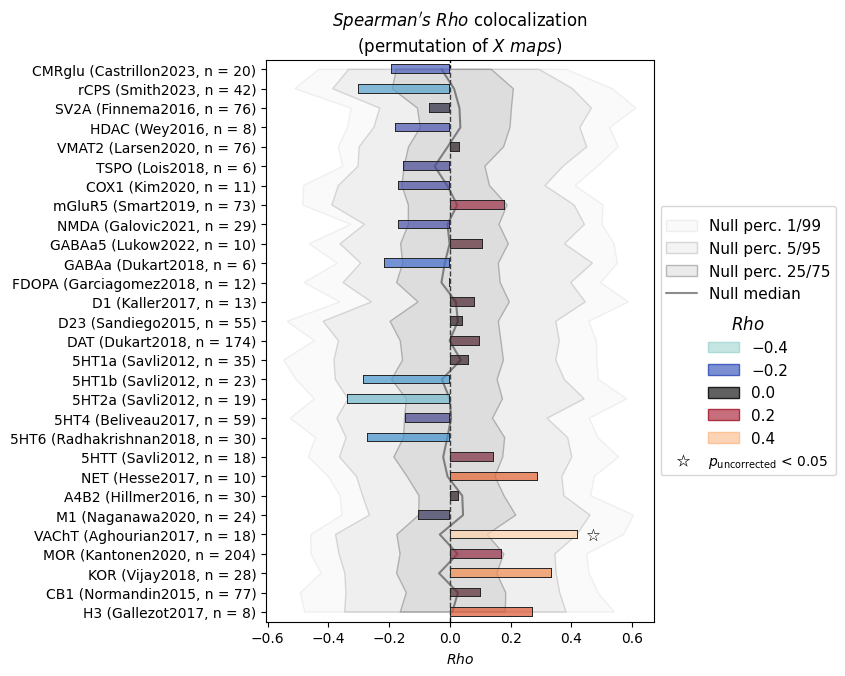

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x313fe4ca0>)

In [9]:
nsp.plot(mc_method="meff")

## Which method should I use?

- **Meff (default)**: The NiSpace default and the right starting point for most analyses. It accounts for the actual correlation structure of your reference maps and is more powerful than Bonferroni without any additional assumptions.
- **maxT / step-maxT**: Excellent alternatives when your colocalization method produces statistics on a comparable scale — that is, Spearman or Pearson correlations, or regression with z-scored X. Computationally free once `permute()` has run. Step-maxT has more power than basic maxT.
- **FDR-BH**: Appropriate when you're comfortable with FDR control rather than FWER — common in exploratory neuroimaging but note that the interpretation differs.
- **Bonferroni**: Rarely justified; Meff is strictly better when your tests are correlated, which they typically are for any standard reference dataset.

## Summary

| Method | Call | Controls |
|--------|------|----------|
| Meff — **NiSpace default** | `nsp.correct_p()` | FWER |
| maxT | `nsp.correct_p(mc_method="maxT")` | FWER |
| step-maxT | `nsp.correct_p(mc_method="step_maxT")` | FWER |
| FDR (Benjamini-Hochberg) | `nsp.correct_p(mc_method="fdr_bh")` | FDR |
| Bonferroni | `nsp.correct_p(mc_method="bonferroni")` | FWER |

Retrieve corrected p-values with `nsp.get_p_values(mc_method=...)` after calling `correct_p()`.

Next: [Notebook 7](intro07_visualization.ipynb) covers how to customize `NiSpace.plot()` and `NiSpace.plot_brain()` to produce publication-quality figures.